In [2]:
#import cupy as cp
import numpy as np
from scipy.signal import lfilter, lp2bp, bilinear
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt
#from scipy.signal import butter, lfilter, wiener, freqz

### Introdução a filtros adaptativos
---
Um filtro é um dispositivo que mapeia seu sinal de entrada para outro sinal de saída facilitando a extração das informações desejadas contidas no sinal de entrada. Um filtro adaptativo é em sua maioria um filtro digital que tem caracteristicas de autoajuste. Esse tipo de filtro é necessário quando as especificações fixas são desconhecidas ou as especificações não podem ser satisfeitas por filtros invariantes no tempo. Eles desempenham um papel importante nos produtos modernos de processamento de sinal digital (DSP) em áreas como cancelamento de eco telefônico, cancelamento de ruído, equalização de canais de comunicação, entre outros. Os filtros adaptativos em suma são lineares, usam seus coeficientes para minimizar os erros, usando uma função de custo onde a mais comum é o Erro Quadrático Médio.

Para entender melhor o conceito de filtros adaptativos, podemos analisar um cancelador de ruídos simples. Conforme mostrado na figura abaixo, o sistema *DSP* consiste em dois canais de conversão **ADC**. O primeiro microfone captura a fala desejada. No entanto, devido ao ambiente ruidoso, o sinal é contaminado com o ruído. Um segundo microfone é usado para capturar o ruído, alimentando assim o fitro adaptativo.

<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Cancelador-de-ruido.png?raw=true"/></center>
$$\text{Fonte: Livro: Digital Signal Processing: Fundamentals and Applications}$$

Neste exemplo podemos assumir que o sinal com ruído é uma versão linear da fonte do ruído, então podemos estimar o ruído no sinal desejado usando um filtro adaptativo, que possui um algoritmo de *Minimos Quadrados Médios* (**LMS**), que ajusta os coeficientes e quando temos $y(n) ≈ n(n)$, podemos usar a expressão de erro e então o ruído é cancelado. O filtro usado no exemplo acima é definido como *Filtro de resposta ao impulso* (**FIR**), o coeficiente $w(n)$ é ajustado pelo algoritmo **LMS**. Onde temos as seguintes expressões:
$$\begin{equation}
y(n) = w(n).x(n) \\
d(n) = s(n) + n(n) \\
e(n) = d(n) - y(n) \\
w(n + 1) = w(n) + 0.01.e(n).x(n)
\end{equation}$$


__Por que os filtros adaptativos são a melhor escolha?__

Filtros adaptativos são a melhor escolha em sistemas onde as características do ambiente ou do sinal variam ao longo do tempo e não podem ser modeladas de forma estática. Eles ajustam seus coeficientes automaticamente para minimizar erros ou alcançar objetivos específicos, como cancelamento de ruído, predição de sinais ou equalização de canais.



### Teoria básica do filtro Wiener
---
O filtro Wiener é um ótimo filtro linear discreto, é baseado em uma abordagem estatistica que visa minimizar o __Erro Quadrático Médio (MSE)__ entre o sinal original e o sinal desejado, usado para restaurar sinais e cancelar ruídos. Na prática os parâmetros que determinam o __MSE__ não está disponíveis, restando estimar de forma direta ou indiretamente, usando os dados disponíveis.


Muitos algoritmos adaptativos podem ser vistos como aproximações do filtro Wiener discreto, onde a saída $y(n)$ é uma soma ponderada, dada por:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$

Em alguns exemplos de cancelamento de ruído, o fitro Wiener ajusta sua saída y(n) para ser o mais próximo do ruído $n(n)$, assim, na saída o ruído é cancelado. Ja em exemplos de filtragem ou recuperação de sinais y(n) se aproxima de s(n). Considere um caso de peso único de $y(n) = wx(n)$ e fazendo algumas manipulações temos:
$$e(n) = d(n) - wx(n) ⟹ e^2(n) = (d(n) - wx(n))^2 = d^2(n) - 2d(n)wx(n) + w^2x^2(n)$$

Usando a expectativa estatistica, temos:
$$E(e^2(n)) = E(d^2(n)) - 2wE(d(n)x(n)) + w^2E(x^2(n))$$
onde:
> $J = E(e^2(n)) =$ erro quadratico médio. \\
  $σ^2 = E(d^2(n)) =$ potência do sinal corrompido. \\
  $P = E(d(n)x(n)) =$ correlação cruzada de d(n) e x(n). \\
  $R = E(x^2(n)) = $ autocorrelação.

Substituindo na equação temos:
$$J = σ^2 - 2w.P + w^2.R$$

A melhor solução para o peso $w$ ocorre quando o $J_{min}$ é alcançado. Quando o MSE de saída é minimizado, o filtro adaptativo representa um modelo para o sistema desconhecido, assim quando fazemos a derivada igual a zero, temos:
$$\frac{dJ}{dw} = -2P + 2wR = 0 \\
w = P.R^{-1}$$

Em geral, o filtro Wiener tem N coeficientes e pode ser escrito em forma de matriz como:
$$\begin{equation}
y(n) = \sum_{k = 0}^{N - 1} w_k x(n - k) = W^T X(n)
\end{equation}$$

Fazendo essa alteração na função **MSE**, temos:
$$J = E(e^2(n)) = E(d(n) - W^TX(n))^2 \\ \begin{equation}
J = σ^2 - 2W^T.P + W^T.R.W
\end{equation}$$

O objetivo é encontrar coeficientes de peso (__W__) que permita uma solução direta que minimize a função (__J__) se o vetor __P__ e a matriz __R__ forem conhecidos. Fazendo a derivada para zero, temos:

$$\frac{dJ}{dW} = -2.P + W.R = 0 \\
W = P. R^{-1}$$

__Qual a função do filtro de Wiener?__

O filtro de Wiener é um filtro projetado para minimizar o erro médio quadrático (MSE) entre o sinal desejado e o sinal estimado. Ele é usado em situações onde o sistema é estacionário e conhecido. Esse filtro ajuda a estimar valores futuros de um sinal baseado no histórico.

>**Prós:** \\
> + Fornece a solução ótima para sinais estacionários.
> + Minimiza o erro médio quadrático (MSE).

> __Contras:__ \\
+ Requer conhecimento prévio da estatística do sinal, o que não é viável em sistemas dinâmicos.
+ Mais complexo computacionalmente em comparação ao LMS.

### Previsão Linear Direta
---

A previsão linear lida com a probabilidade de prever um valor futuro a partir de valores passados observados. Considerando um ponto $x(n)$, usando valores de $x(n - 1) ⋯ x(n - P)$. A previsão pode ser obtida por:
$$\begin{equation}
  x´(n) = \sum_{k = 1}^{P} a_k x(n - k)
\end{equation}$$

A diferença entre $x(n) \ e \ x´(n)$ é dada pelo erro de previsão:
$$e_f(n) = x(n) - x´(n)$$

### Algoritmo de descida mais íngrime
---
O método de descida mais íngreme pode ser considerado um algoritmo eficiente do tipo gradiente, no sentido de que ele trabalha com o verdadeiro vetor de gradiente, e não com uma estimativa dele.

Como vimos, resolver a solução de *Wiener* requer muitos cálculos, para isso usamos um algoritmo **LMS** que usa o algoritmo de descida mais íngrime para minimizar o **MSE**.
$$\begin{equation}
w(n + 1) = w(n) - μ\frac{dJ}{dw(n)}
\end{equation}$$

onde μ é a constante que controla a velocidade de convergência.

Para caso geral, temos: $y(n) = W(n)^T.X(n)$ \
Em forma vetorial: $w(n + 1) = W(n) - μΔJ_{W(n)}$

### Algoritmo de mínimos quadrados médios (**LMS**)
---

A aplicação do algoritmo de descida mais íngrime ainda inclui cálculos estatísticos de um bloco de dados. Para solucionar usamos um algortimo baseado em amostra **LMS**, onde:
$$J = e^2(n) = (d(n) - w(n)x(n))^2 \\
\frac{dJ}{dw(n)} = -2e(n)x(n)$$

Substituindo na expressão do filtro de descida, encontramos o *LMS* para atualizar um caso de peso único.
$$\begin{equation}
w(n + 1) = W(n) +2μ e(n)x(n)
\end{equation}$$
onde $ 0 < μ < \frac{1}{λ_{max}}, λ_{max}$ é o autovalor da matriz $R = E(X^T(n)X(n))$

Para caso geral, temos:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$
$$w_k(n + 1) = W_k(n) +2μ e(n)x(n - k)$$

Em forma vetorial: $W(n + 1) = W(n) +2μ e(n)X(n)$

### Algoritmo de mínimos quadrados recursivos
---

Os algoritmos *RLS* visam minimizar a soma dos quadrados da diferença entre o sinal desejado e o sinal de saída do filtro. Eles calculam os coeficientes do filtro de forma recursiva, são mais rápidos e possuem excelente desempenho em relação ao *LMS*.

Dado um filtro adaptivo linear $y(n) = W^T(n) X(n)$, onde:

$$W(n) = [w_0(n) w_1(n) ⋯ w_{N - 1}(n)]^T$$
$$X(i) = [x(i) x(i - 1) ⋯ x(i - N + 1)]^T$$

Incluindo a função de erro ponderado exponencial com um fator de esquecimento λ.
$$\begin{equation}
𝜻(n) = \sum_{i = 1}^{n} λ^{n - i} e^2(n)
\end{equation}$$
com $0 < λ < 1 \ e \ e(i) = d(i) - W^T(n)X(i)$

Derivando a função $𝜻(n)$ por W(n) encontramos:
$$\sum_{i = 1}^{n} λ^{n - i} X^T(i)W(n) = \sum_{i = 1}^{n} λ^{n - i} X(i)d(i) $$

Do lado esquerdo temos a matriz de correlação $R$ e do lado direito temos o vetor de correlação cruzada $P$ e assim temos:
$$\begin{equation}
R(n) = \sum_{i = 1}^{n} λ^{n - i} X^T(i)W(n) = λ.R(n - 1) + X(n)X^T(n)
\end{equation}$$
$$\begin{equation}
P(n) = \sum_{i = 1}^{n} λ^{n - i} X(i)d(i) = λ.P(n - 1) + d(n)X(n)
\end{equation}$$

Realizando várias manipulações encontramos todos os parametros para o filtro RLS. Semelhante ao LMS, ao omitir o índice de tempo para $w_k(n)$, ou seja, $w_k = w_r(n)$, podemos concluir o algoritmo *RLS* com as seguintes etapas:

> 1. Iniciar $W = [w_0(n) w_1(n) ⋯ w_{N - 1}(n)]^T$ para valores arbitrários. \\
  Iniciar Q = δ.I, onde I é a matriz identidade e δ é o inverso da potência do sinal de entrada.
> 2. Calcule o vetor de inovação e ganho.
  $$α = d(n) - X^T(n)W$$
  $$K = \frac{Q.X(n)}{λ + X^T(n).Q.X(n)}$$
> 3. Atualize os coeficientes do filtro.
  $$ W = W + k.α$$
> 4. Atualize a matriz Q, produza a saída do filtro e medir o erro.
  $$Q = [Q - kX^T(n).Q]/λ$$
  $$y(n) = W^TX(n)$$
  $$e(n) = d(n) - y(n)$$

### Exemplo 1
---
Neste exemplo, o algoritmo LMS é utilizado para cancelar ruídos adaptativamente, onde o sinal de entrada é contaminado por ruído e o filtro LMS ajusta-se para minimizar o erro entre o sinal desejado e o sinal de saída.

In [ ]:
# Parâmetros do sinal
fs = 8000
mu = 0.01
N = 2000

# Sinal e ruído
wen = np.sin(2 * np.pi * 100 * np.arange(N) / fs)                               # Esta linha gera um sinal senoidal de 100 Hz.
t = np.arange(len(wen)) / fs                                                    # Cria índices de 0 até o comprimento de 'wen'.
x = np.random.randn(len(wen))                                                   # Gera um sinal aleatório gaussiano (ruído branco) com 'N' amostras.
n = lfilter([0, 0, 0, 0, 0, 0.5], 1, x)                                         # Filtro FIR com atraso de 5 amostras, um filtro FIR puro.
d = wen + n

# Filtro LMS
tam = 21
w = np.zeros(tam)                                                               # Inicia os coeficientes adaptativos
y = np.zeros(len(t))                                                            # Inicia a saída do filtro
e = y                                                                           # Inicia o erro do filtro
for m in range(tam+1, len(t)):                                                  # Inicia o laço da posição 22 e vai ate len(t)
  sum = 0;
  for k in range(tam):
    sum += w[k] * x[m-k]
  y[m] = sum
  e[m] = d[m] - y[m]
  for k in range(tam):
    w[k] = w[k] + (mu * e[m] * x[m-k])

# Análise Espectral do sinal original.
WEN = 2 * np.abs(fft(wen)) / len(wen)
# Cálculo do espectro de amplitude unilateral do sinal corrompido.
D = 2 * np.abs(fft(d)) / len(d)
# Cálculo do espectro de amplitude unilateral do sinal cancelado do ruido.
E = 2 * np.abs(fft(e)) / len(e)

# Vetor de frequências.
f = np.arange(0, (len(wen) / 2) + 1) * fs / len(wen)                            # Escala os valores para que correspondam a uma frequência de 8000HZ

# Conversão para NumPy para visualização
"""
t = np.asnumpy(t)
d = np.asnumpy(d)
y = np.asnumpy(y)
e = np.asnumpy(e)"""


'\nt = np.asnumpy(t)\nd = np.asnumpy(d)\ny = np.asnumpy(y)\ne = np.asnumpy(e)'

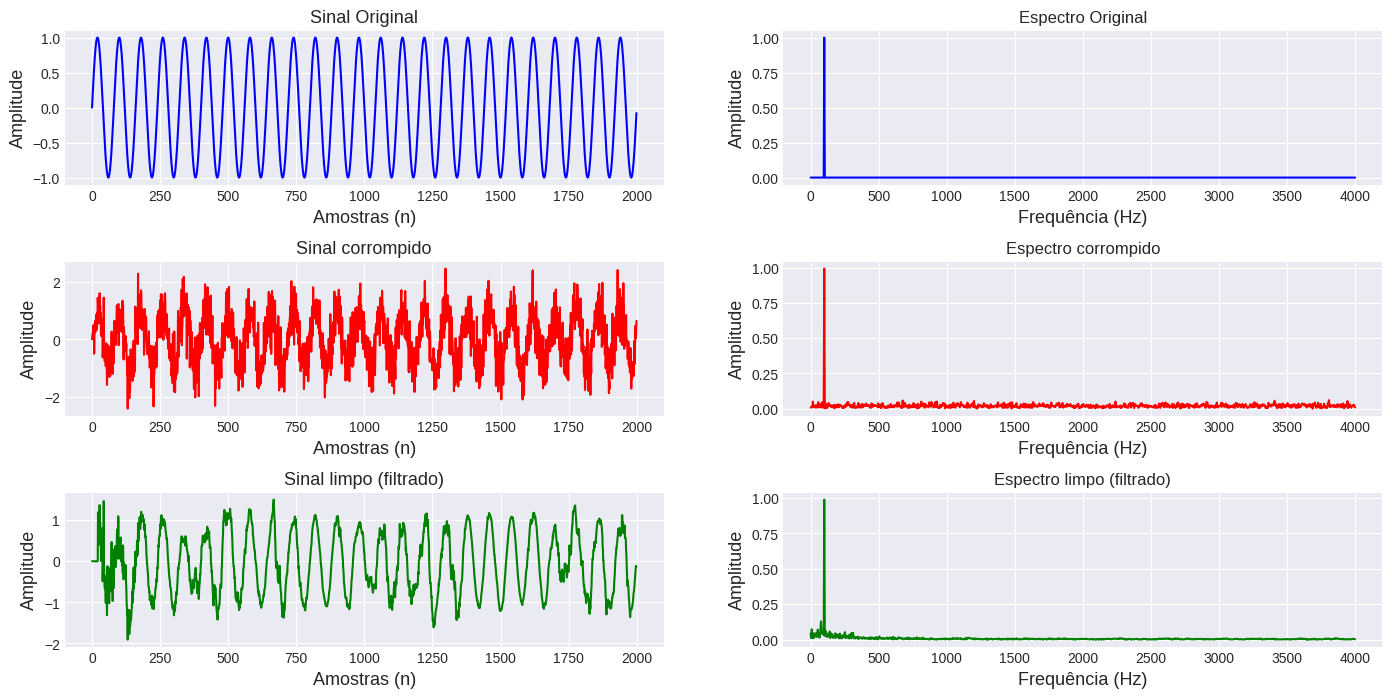

In [ ]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(3, 2, figsize=(17, 8))
fig.subplots_adjust(hspace=0.5)

# Configurando uma caracteristica geral.
for ax in axis.flatten():
    ax.set_xlabel('Amostras (n)', fontsize = 13)
    ax.set_ylabel('Amplitude', fontsize = 13)

# Plotando o gráfico do Sinal original.
axis[0, 0].plot(wen, color='blue')
axis[0, 0].set_title('Sinal Original', fontsize = 13)

# Plotando o gráfico do Espectro do sinal original.
axis[0, 1].plot(f, WEN[:len(f)], color='blue')
axis[0, 1].set_title('Espectro Original')
axis[0, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

# Plotando o gráfico do Sinal corrompido.
axis[1, 0].plot(d, color='red')
axis[1, 0].set_title('Sinal corrompido', fontsize = 13)

# Plotando o gráfico do Espectro do sinal corrompido.
axis[1, 1].plot(f, D[:len(f)], color='red')
axis[1, 1].set_title('Espectro corrompido')
axis[1, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

# Plotando o gráfico do Sinal limpo (filtrado).
axis[2, 0].plot(e, color='green')
axis[2, 0].set_title('Sinal limpo (filtrado)', fontsize = 13)

# Plotando o gráfico do Espectro do sinal limpo (filtrado).
axis[2, 1].plot(f, E[:len(f)], color='green')
axis[2, 1].set_title('Espectro limpo (filtrado)')
axis[2, 1].set_xlabel('Frequência (Hz)', fontsize = 13)

plt.show()

### Identificação de Sistema Adaptativa com Algoritmo LMS
---
No processo de identificação de sistema adaptativa, o objetivo é modelar ou aproximar um sistema desconhecido usando um filtro adaptativo, geralmente um filtro FIR (Finite Impulse Response) ajustado com o algoritmo LMS (Least Mean Squares). Essa técnica é amplamente utilizada em cenários onde o comportamento de um sistema não é totalmente conhecido, mas um conjunto de entradas e saídas do sistema está disponível para análise.

Como Funciona o Algoritmo LMS na Identificação de Sistemas

+ Sinal de Entrada ($x[n]$): Um sinal conhecido, como um sinal senoidal ou ruído branco, é aplicado tanto ao sistema desconhecido quanto ao filtro adaptativo. Esse sinal funciona como uma entrada de teste para caracterizar o sistema.

+ Sistema Desconhecido: Esse sistema possui uma resposta ao impulso que queremos identificar. Quando o sinal de entrada passa pelo sistema desconhecido, ele gera uma saída desejada $d[n]$, que representa a resposta verdadeira do sistema.

+ Filtro Adaptativo: O filtro adaptativo tenta "aprender" a resposta ao impulso do sistema desconhecido. Inicialmente, o filtro começa com coeficientes arbitrários (geralmente zeros) e ajusta esses coeficientes a cada iteração para reduzir o erro.

+ Erro ($e[n]$): O erro é a diferença entre a saída do filtro adaptativo $(y[n])$ e a saída desejada $(d[n])$. Esse erro indica quão próximo o filtro está de imitar o sistema desconhecido.

+ Ajuste dos Coeficientes: Com base no erro, o algoritmo LMS ajusta os coeficientes do filtro adaptativo. Esse ajuste é feito para minimizar o erro médio quadrático *(Mean Squared Error - MSE)* entre a saída do filtro e a saída desejada, movendo os coeficientes na direção que reduz o erro.

### Aplicações: Cancelamento de ruído, Modelagem de sistema e Aprimoramento de linha.

### __Cancelamento de Ruído (Noise Cancellation)__:

Como vimos anteriormente, o sistema *DSP* consiste em dois canais *ADC*. O primeiro captura o sinal original $s(n)$ e o sinal com ruído $n(n)$devido ao ambiente ruidoso. O segundo captura somente o ruído que irá alimentar o filtro adaptivo que usará um algoritmo adaptivo para ajustar os coeficientes e ter na saída uma estimativa do sinal limpo, anulando o ruído do ambiente.

O cancelamento de ruído é uma técnica fundamental em processamento digital de sinais, usada para reduzir ou eliminar ruídos indesejados de sinais de interesse. O objetivo é melhorar a qualidade do sinal principal, isolando-o de interferências sonoras. A técnica mais comum para cancelamento de ruído é o uso de filtros adaptativos, especialmente o filtro LMS (Least Mean Square). Esse filtro aprende em tempo real a característica do ruído e o subtrai do sinal original. Um exemplo típico de aplicação é o cancelamento de ruído em comunicações telefônicas, onde interferências externas ou ruídos de fundo podem ser removidos sem comprometer a clareza do sinal de voz.

+ Principais Benefícios:
  - Melhoria da inteligibilidade do sinal.
  - Redução de interferências que podem comprometer a comunicação.
  - Aplicação em fones de ouvido com cancelamento de ruído ativo, onde o dispositivo é capaz de isolar sons indesejados para uma experiência auditiva mais limpa.

### __Modelagem de Sistema (System Modeling):__

Outra aplicação do filtro adaptativo é a modelagem de sistema. O filtro adaptativo pode continuar rastreando o comportamento de um sistema desconhecido usando a entrada e a saída do sistema desconhecido após a convergência do filtro adaptativo, a saída do filtro adaptativo $y(n)$ será o mais próximo possível da saída do sistema desconhecido. Como tanto o sistema desconhecido quanto o filtro adaptativo respondem à mesma entrada, a função de transferência do filtro adaptativo se aproximará daquela do sistema desconhecido.

A modelagem de sistema refere-se à criação de um modelo matemático que representa as características de um sistema físico. Em processamento de sinais, a modelagem de sistemas é essencial para simular e prever o comportamento de sistemas complexos, como filtros ou canais de comunicação. A modelagem pode ser feita usando técnicas adaptativas, que permitem que o modelo ajuste automaticamente seus parâmetros com base nas condições de entrada. Esse processo é útil em sistemas onde as características variam ao longo do tempo e é necessário um acompanhamento dinâmico das mudanças.

+ Principais Benefícios:
  - Previsão e controle do comportamento de sistemas físicos complexos.
  - Otimização de desempenho em sistemas de comunicação, ao se adaptar a diferentes condições do canal.
  - Aplicação em engenharia para o desenvolvimento de sistemas robustos e eficientes.

  No exemplo abaixo, usamos uma entrada que consiste em tons de 500, 1500 e 2500 Hz. Podemos prever que a saída do sistema desconhecido conterá apenas um tom de 1500 Hz, já que os outros dois tons são rejeitados pelo sistema desconhecido. No domínio do tempo, as formas de onda de saída do sistema desconhecido d(n) e a saída do filtro adaptativo y(n) são quase idênticas
após 70 amostras quando o algoritmo LMS converge.

In [ ]:
# Parâmetros do sistema
fs = 8000
T = 1 / fs

wa1 = 1400 * 2 * np.pi                                                          # Frequência de corte inferior em rad/s
wa2 = 1600 * 2 * np.pi                                                          # Frequência de corte superior em rad/s

# Transformação das frequências para o domínio digital
wd1 = (2 / T) * np.tan(wa1 * T / 2)
wd2 = (2 / T) * np.tan(wa2 * T / 2)

# Cálculo da largura de banda e da frequência central
BW = wd2 - wd1
w0 = np.sqrt(wd2 * wd1)

# Projeto do filtro passa-banda usando lp2bp
B, A = lp2bp([1], [1], w0, BW)

# Transformação bilinear para o domínio digital
b, a = bilinear(B, A, fs)

# Sinais de entrada e saída do sistema
t = np.arange(0, 0.1 + T, T)
x = np.cos(2 * np.pi * 500 * t) + np.sin(2 * np.pi * 1500 * t) + np.cos(2 * np.pi * 2500 * t + np.pi / 4)
d = lfilter(b, a, x)

# Parâmetros do algoritmo LMS
mu = 0.01
w = np.zeros(21)
y = np.zeros(len(t))
e = np.zeros(len(t))

# Algoritmo LMS
tam = 21
for m in range(tam+1, len(t)):                                                  # Inicia o laço da posição 22 e vai ate len(t)
  sum = 0;
  for k in range(tam):
    sum += w[k] * x[m-k]
  y[m] = sum
  e[m] = d[m] - y[m]
  for k in range(tam):
    w[k] = w[k] + (mu * e[m] * x[m-k])

# Espectro de amplitude
X = 2 * np.abs(np.fft.fft(x)) / len(x)
D = 2 * np.abs(np.fft.fft(d)) / len(d)
Y = 2 * np.abs(np.fft.fft(y)) / len(y)

# Vetor de frequências.
f = np.arange(0, (len(x) / 2) + 1) * fs / len(x)                            # Escala os valores para que correspondam a uma frequência de 8000HZ

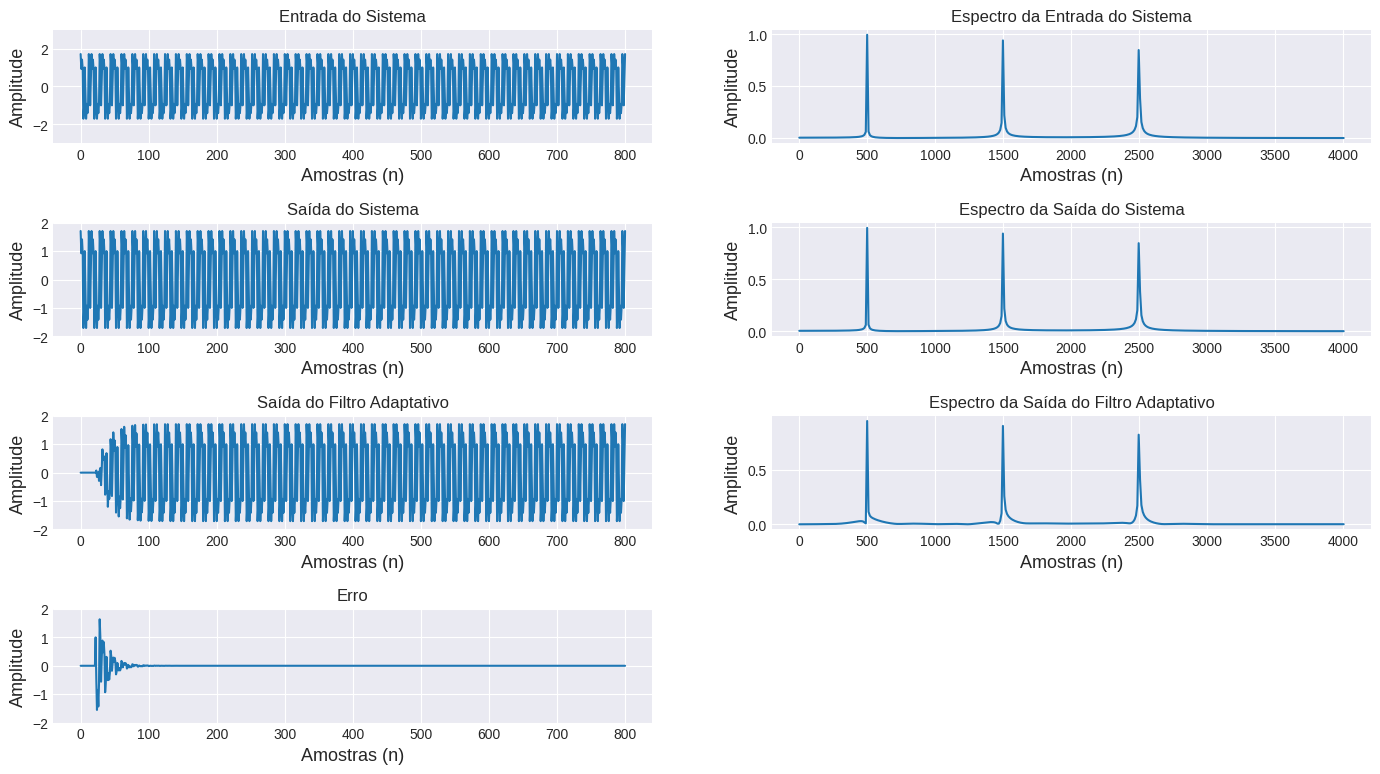

In [ ]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(4, 2, figsize=(17, 9))
fig.subplots_adjust(hspace=0.7)

for ax in axis.flatten():
    ax.set_xlabel('Amostras (n)', fontsize = 13)
    ax.set_ylabel('Amplitude', fontsize = 13)

# Plotando gráfico do Sinal Original.
axis[0, 0].plot(x)
axis[0, 0].set_title("Entrada do Sistema")
axis[0, 0].set_ylim([-3, 3])

# Plotando gráfico do Sinal Saída.
axis[1, 0].plot(d)
axis[1, 0].set_title("Saída do Sistema")
axis[1, 0].set_ylim([-2, 2])

# Plotando gráfico do Sinal Filtro.
axis[2, 0].plot(y)
axis[2, 0].set_title("Saída do Filtro Adaptativo")
axis[2, 0].set_ylim([-2, 2])

# Plotando gráfico do Sinal Erro.
axis[3, 0].plot(e)
axis[3, 0].set_title("Erro")
axis[3, 0].set_ylim([-2, 2])

# Plotando gráfico do Sinal Original.
axis[0, 1].plot(f, X[:len(f)])
axis[0, 1].set_title("Espectro da Entrada do Sistema")

# Plotando gráfico do Sinal Saída.
axis[1, 1].plot(f, D[:len(f)])
axis[1, 1].set_title("Espectro da Saída do Sistema")

# Plotando gráfico do Sinal Filtro.
axis[2, 1].plot(f, Y[:len(f)])
axis[2, 1].set_title("Espectro da Saída do Filtro Adaptativo")

# Desativa o último eixo [3,1]
fig.delaxes(axis[3, 1])

plt.show()

####  __Aprimoramento de linha.__

Estudamos a filtragem adaptativa por meio de outro exemplo de aplicação: aprimoramento de linha. Se um conteúdo de frequência de sinal
é muito estreito em comparação com a largura de banda e muda com o tempo, então o sinal pode ser aprimorado eficientemente pelo filtro adaptativo, que é o aprimoramento de linha.

A linha aprimorada consiste em um elemento de atraso para atrasar o sinal corrompido por amostras $Δ$ para produzir uma entrada para o filtro adaptativo.
O filtro adaptativo é, na verdade, um preditor linear do sinal de banda estreita desejado. Um *filtro adaptativo FIR* de dois toques pode prever uma sinusoide. O valor de Δ é geralmente determinado por experimentos ou experiência
na prática para atingir o melhor sinal aprimorado.


In [3]:
# Parâmetros do sistema
fs = 8000
T = 1 / fs
t = np.arange(0, 0.1, T)

# Geração do sinal
n = np.random.randn(len(t))                                                     # Ruído branco gaussiano
d = np.cos(2 * np.pi * 500 * t) + n                                             # Sinal de 500 Hz com ruído
x = lfilter([0, 0, 0, 0, 0, 1], [1], d)                                         # Filtro FIR com atraso de 5 amostras

# Algoritmo LMS
mu = 0.001
w = np.zeros(21)
y = np.zeros(len(t))
e = np.zeros(len(t))

# Filtragem adaptativa usando o algoritmo LMS
tam = 21
for m in range(tam+1, len(t)):                                                  # Inicia o laço da posição 22 e vai ate len(t)
  sum = 0;
  for k in range(tam):
    sum += w[k] * x[m-k]
  y[m] = sum
  e[m] = d[m] - y[m]
  for k in range(tam):
    w[k] = w[k] + (mu * e[m] * x[m-k])

# Espectros de amplitude
D = 2 * np.abs(np.fft.fft(d)) / len(d)
Y = 2 * np.abs(np.fft.fft(y)) / len(y)

f = np.arange(0, (len(x) / 2) + 1) * fs / len(x)                                # Escala os valores para que correspondam a uma frequência de 8000HZ

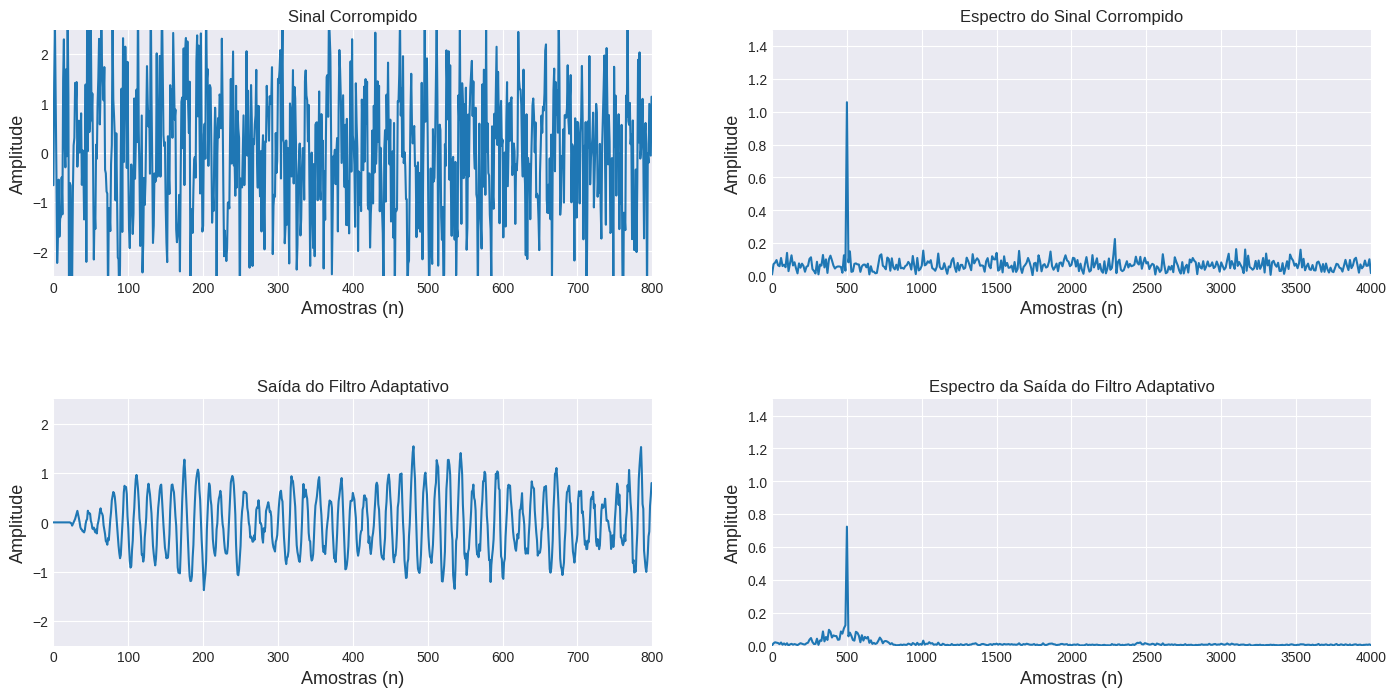

In [8]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(2, 2, figsize=(17, 8))
fig.subplots_adjust(hspace=0.5)

for ax in axis.flatten():
    ax.set_xlabel('Amostras (n)', fontsize = 13)
    ax.set_ylabel('Amplitude', fontsize = 13)

# Plotando gráfico do Sinal Corrompido.
axis[0, 0].plot(d)
axis[0, 0].axis([0, len(x), -2.5, 2.5])
axis[0, 0].set_title("Sinal Corrompido")

# Plotando gráfico do Sinal Filtro.
axis[1, 0].plot(y)
axis[1, 0].axis([0, len(y), -2.5, 2.5])
axis[1, 0].set_title("Saída do Filtro Adaptativo")

# Plotando gráfico do Sinal Saída.
axis[0, 1].plot(f, D[:len(f)])
axis[0, 1].axis([0, fs / 2, 0, 1.5])
axis[0, 1].set_title("Espectro do Sinal Corrompido")

# Plotando gráfico do Sinal Filtro.
axis[1, 1].plot(f, Y[:len(f)])
axis[1, 1].axis([0, fs / 2, 0, 1.5])
axis[1, 1].set_title("Espectro da Saída do Filtro Adaptativo")

plt.show()

### __Cancelamento periódico de interferência__

Um sinal de áudio pode ser corrompido por interferência periódica e nenhuma referência de ruído disponível. Tais exemplos incluem a reprodução de fala ou música com a interferência de zumbido de fita, ou ruído sintonizável, ou
motor de veículo, ou interferência de linha de energia. O filtro adaptativo usa a versão atrasada do sinal corrompido x(n) para prever a interferência periódica. O número de amostras atrasadas é selecionado por meio de experimentos que determinam o desempenho do filtro adaptativo. Após a convergência, o filtro adaptativo preverá a interferência como:
$$\begin{equation}
y(n) = \sum_{k = 0}^{N - 1} w_k(n) x(n - k) ≈ Acos(2\pi fn/fs)
\end{equation}$$

Portanto, o sinal de erro contém apenas o sinal de áudio desejado:
$$e(n) ≈ s(n)$$

### __Cancelamento de interferência de eletrocardiograma.__

Na gravação de eletrocardiogramas **(ECG)**, frequentemente existe
interferência indesejada de 60 Hz, juntamente com seus harmônicos, nos dados registrados. Essa interferência vem da linha de energia, incluindo efeitos de indução magnética, correntes de deslocamento em condutores ou no corpo do paciente e interconexões e imperfeições do equipamento.

A entrada primária é retirada do pré-amplificador de ECG, enquanto uma entrada de referência de 60 Hz é retirada de uma tomada de parede com atenuação adequada. Após o condicionamento adequado do sinal, a interferência digital $x(n)$ é adquirida pelo processador de sinal digital $(DS)$. Um filtro FIR adaptativo com N taps e o algoritmo *LMS* podem ser usados para esta aplicação:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$

Então, após a convergência do filtro adaptativo, a interferência estimada é subtraída do sinal primário do pré-amplificador de ECG para produzir o sinal de saída e(n), no qual a interferência de 60 Hz é cancelada:

$$e(n) = d(n) - y(n) = s(n) + n(n) - x (n) ≈ s(n)$$

No monitoramento fetal, é importante cancelar o ECG da mãe, pois o ECG fetal ajuda a monitorar a condição do bebê antes e durante o parto. No entanto, o sinal captado do abdômen da mãe é frequentemente contaminado por ruídos, como atividade muscular, movimento fetal e o próprio ECG materno. Para reduzir essa interferência, são usadas quatro ou mais derivações torácicas como referência. Um eletrodo no abdômen captura o sinal fetal $d(n)$, que pode estar misturado com o ECG da mãe. Um filtro adaptativo é então aplicado para prever e subtrair o ECG materno, isolando o sinal do bebê.

### __Cancelamento de Eco em Circuitos Telefônicos de Longa Distância.__

Nas transmissões telefônicas de longa distância, problemas de incompatibilidade de impedância podem causar vazamentos de sinal, conhecidos como eco. Isso acontece porque o balanceamento das redes no híbrido nunca é perfeito devido a fatores como variações de temperatura e degradação das linhas.

Por exemplo, quando o falante B fala, seu sinal $x_B(n)$ chega ao falante A, mas parte dele vaza e retorna para B, fazendo com que ele ouça sua própria voz como eco. O mesmo pode acontecer no caminho inverso, com o falante A.

Para resolver esse problema, usa-se um *filtro adaptativo* em cada extremidade do sistema. No lado do falante A, o filtro usa o sinal de entrada de B como referência e ajusta seus coeficientes para aproximar sua saída ao sinal vazado, cancelando o eco. Esse processo melhora a qualidade das chamadas e reduz desconfortos durante a comunicação.

$$y_A(n) = \sum_{k = 0}^{N - 1} w_k(n)x_B(n - k) ≈ x'_B (n)$$

### Referências
---
1. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019
2. **Moodle USP**. *Filtros de Wiener*. Disponível em: [https://edisciplinas.usp.br/.../aula5.pdf](https://edisciplinas.usp.br/pluginfile.php/5814216/mod_resource/content/1/APDS-Quarentena-aula5.pdf). Acessado em: 23 de novembro de 2024.
3. **Aprenda Fácil**. *O que é: Filtro de Wiener - Entenda sua Aplicação*. Disponível em: [https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/](https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/). Acessado em: 23 de novembro de 2024
4. **Scipy**. *scipy.signal.wiener*. Disponível em: [https://docs.scipy.org/.../scipy.signal.wiener.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.wiener.html). Acessado em: 26 de novembro de 2024.
5. **Wikipedia**. *Wiener filter*. Disponível em: [https://en.wikipedia.org/wiki/Wiener_filter](https://en.wikipedia.org/wiki/Wiener_filter)
6. **DINIZ, Paulo S. R.**.*Adaptive Filtering: Algorithms and Practical Implementation.*. 4th ed. Universidade Federal do Rio de Janeiro. Rio de Janeiro, Brazil